
MODULE 1 : CSV TO PARQUET CONVERSION

FIRST 5 ROWS
                         Data  Temperatura  Humidade
0  06/01/2023 19:00:00 -03:00         27.2      82.6
1  06/01/2023 20:00:00 -03:00         27.0      83.0
2  06/01/2023 21:00:00 -03:00         27.0      83.0
3  06/01/2023 22:00:00 -03:00         26.7      83.9
4  06/01/2023 23:00:00 -03:00         26.5      85.4

PARQUET FILE CREATED SUCCESSFULLY

MODULE 2 : LOAD PARQUET DATA

PARQUET DATA LOADED

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1226 entries, 2023-01-06 19:00:00-03:00 to 2023-04-26 04:00:00-03:00
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperatura  1226 non-null   float64
 1   Humidade     1226 non-null   float64
dtypes: float64(2)
memory usage: 28.7 KB
None

MODULE 3 : FEATURE STANDARDIZATION

CREATING DERIVED FEATURES

FEATURE MATRIX
                           Temperatura  Humidade  Temp_Change  \
Data              

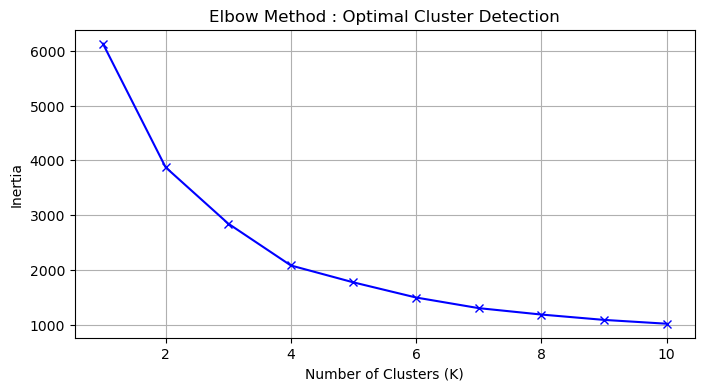


MODULE 5 : CLUSTER DISCOVERY

CLUSTER ASSIGNMENT COMPLETED

CLUSTER DISTRIBUTION
Cluster_Label
Rapid Change Zone    743
Humid Region         350
Stable Weather       133
Name: count, dtype: int64

MODULE 6 : SILHOUETTE VALIDATION

--- CLUSTERING HEALTH REPORT ---

Silhouette Coefficient: 0.4018

INTERPRETATION:
Moderate cluster structure detected.

MODULE 7 : SENSOR VISUALIZATION


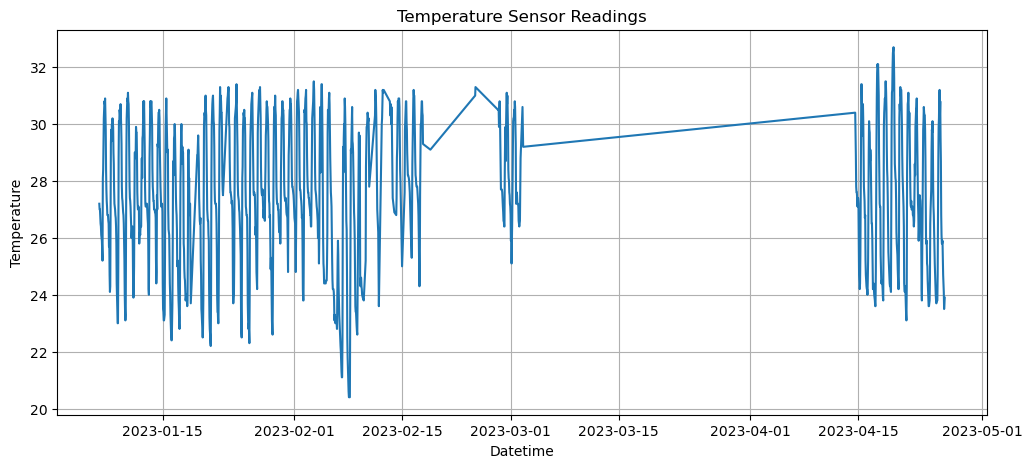

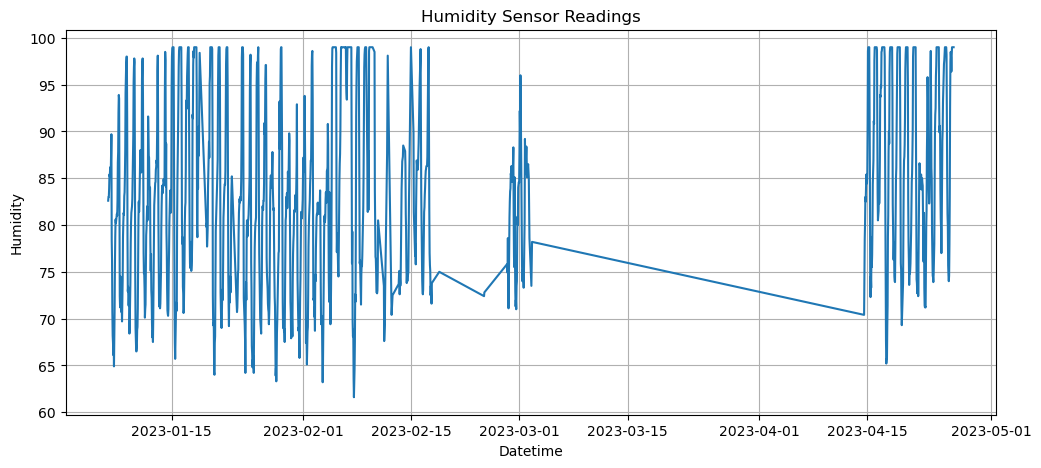


MODULE 8 : CLUSTER VISUALIZATION


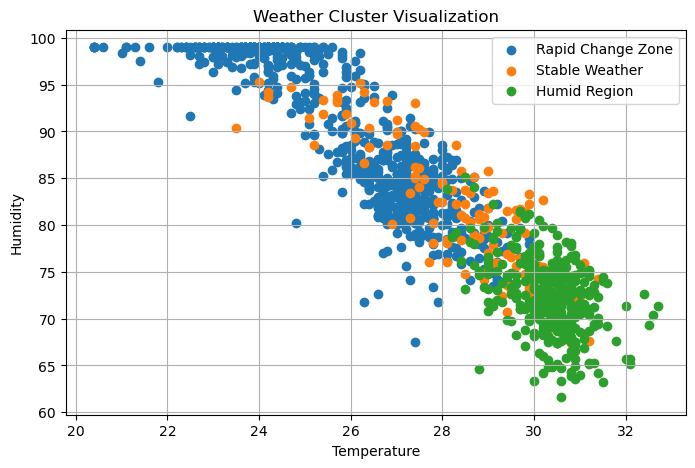


MODULE 9 : CLUSTER DISTRIBUTION
Cluster_Label
Rapid Change Zone    743
Humid Region         350
Stable Weather       133
Name: count, dtype: int64


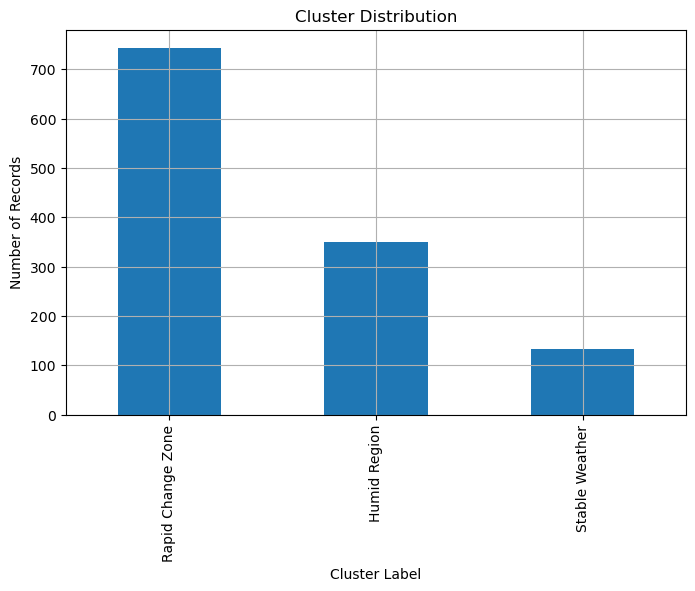


MODULE 10 : CENTROID ANALYSIS

CLUSTER CENTROIDS
   Temperatura   Humidade  Temp_Change  Humidity_Change  Rolling_Var
0    28.463158  81.300000     2.151128        -8.077444     2.643802
1    30.344000  72.346571     0.010000        -0.342286     6.281936
2    25.961777  89.221534    -0.394213         1.629206     2.009109

FINAL CLUSTERED PARQUET FILE SAVED

PR_27 PRACTICAL COMPLETED


In [6]:
# ==========================================
# PR_27
# UNSUPERVISED CLUSTERING USING
# WEATHER STATION SENSOR DATA
# CSV TO PARQUET WORKFLOW
# WITHOUT WARNINGS
# ==========================================

# ==========================================
# FIX KMEANS WARNING
# ==========================================

import os

# Prevent MKL memory leak warning on Windows

os.environ["OMP_NUM_THREADS"] = "5"

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import warnings

# Hide sklearn warnings

warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

# ==========================================
# MODULE 1 :
# CSV INGESTION AND PARQUET CONVERSION
# ==========================================

print("\n===================================")
print("MODULE 1 : CSV TO PARQUET CONVERSION")
print("===================================")

"""
DEFINITION:
This module converts CSV weather
sensor data into Parquet format
for high-speed analytical workflows.
"""

# ---------- LOAD CSV DATASET ----------

df = pd.read_csv(
    "B2K weather station.csv"
)

print("\nFIRST 5 ROWS")
print(df.head())

# ---------- DATETIME CONVERSION ----------

df['Data'] = pd.to_datetime(

    df['Data'],

    dayfirst=True,

    errors='coerce'

)

# Remove invalid datetime rows

df = df.dropna(
    subset=['Data']
)

# ---------- SET DATETIME INDEX ----------

df = df.set_index('Data')

# Sort sequentially

df = df.sort_index()

# ---------- CONVERT SENSOR VALUES ----------

df['Temperatura'] = pd.to_numeric(

    df['Temperatura'],

    errors='coerce'

)

df['Humidade'] = pd.to_numeric(

    df['Humidade'],

    errors='coerce'

)

# Remove invalid rows

df = df.dropna(
    subset=[
        'Temperatura',
        'Humidade'
    ]
)

# ---------- KEEP REQUIRED COLUMNS ----------

df = df[[
    'Temperatura',
    'Humidade'
]]

# ---------- SAVE AS PARQUET ----------

df.to_parquet(

    "weather_station.parquet",

    compression='snappy'

)

print("\nPARQUET FILE CREATED SUCCESSFULLY")


# ==========================================
# MODULE 2 :
# LOAD PARQUET DATA
# ==========================================

print("\n===================================")
print("MODULE 2 : LOAD PARQUET DATA")
print("===================================")

"""
DEFINITION:
Parquet acts as the
high-speed analytical working memory.
"""

# ---------- LOAD PARQUET ----------

df = pd.read_parquet(
    "weather_station.parquet"
)

print("\nPARQUET DATA LOADED")

print("\nDATASET INFO")
print(df.info())


# ==========================================
# MODULE 3 :
# FEATURE STANDARDIZATION
# ==========================================

print("\n===================================")
print("MODULE 3 : FEATURE STANDARDIZATION")
print("===================================")

"""
DEFINITION:
Standardization ensures all features
contribute equally to Euclidean distance.
"""

# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("\nCREATING DERIVED FEATURES")

# ---------- TEMPERATURE CHANGE ----------

"""
Temp_Change represents
speed of temperature variation.
"""

df['Temp_Change'] = (

    df['Temperatura']

    .diff()

    .fillna(0)

)

# ---------- HUMIDITY CHANGE ----------

"""
Humidity_Change represents
speed of humidity variation.
"""

df['Humidity_Change'] = (

    df['Humidade']

    .diff()

    .fillna(0)

)

# ---------- ROLLING VARIANCE ----------

"""
Rolling_Var measures
signal stability.
"""

df['Rolling_Var'] = (

    df['Temperatura']

    .rolling(window=10)

    .var()

    .fillna(0)

)

# ---------- FINAL FEATURE MATRIX ----------

X = df[[

    'Temperatura',

    'Humidade',

    'Temp_Change',

    'Humidity_Change',

    'Rolling_Var'

]]

print("\nFEATURE MATRIX")
print(X.head())

# ---------- STANDARD SCALER ----------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nFEATURE STANDARDIZATION COMPLETED")


# ==========================================
# MODULE 4 :
# ELBOW METHOD
# ==========================================

print("\n===================================")
print("MODULE 4 : ELBOW METHOD")
print("===================================")

"""
DEFINITION:
The Elbow Method identifies
the optimal number of clusters.
"""

# ---------- CALCULATE INERTIA ----------

inertia_scores = []

K_range = range(1, 11)

for k in K_range:

    model = KMeans(

        n_clusters=k,

        init='k-means++',

        n_init=10,

        random_state=42

    )

    model.fit(X_scaled)

    inertia_scores.append(
        model.inertia_
    )

print("\nINERTIA SCORES")
print(inertia_scores)

# ---------- ELBOW VISUALIZATION ----------

plt.figure(figsize=(8,4))

plt.plot(

    K_range,

    inertia_scores,

    'bx-'

)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.title(
    "Elbow Method : Optimal Cluster Detection"
)

plt.grid(True)

plt.show()


# ==========================================
# MODULE 5 :
# CLUSTER DISCOVERY
# ==========================================

print("\n===================================")
print("MODULE 5 : CLUSTER DISCOVERY")
print("===================================")

"""
DEFINITION:
K-Means identifies inherent
hidden patterns inside weather data.
"""

# ---------- SELECT OPTIMAL K ----------

optimal_k = 3

# ---------- FINAL MODEL ----------

final_model = KMeans(

    n_clusters=optimal_k,

    init='k-means++',

    n_init=10,

    random_state=42

)

# ---------- ASSIGN CLUSTERS ----------

cluster_labels = final_model.fit_predict(
    X_scaled
)

# ---------- MERGE CLUSTERS ----------

df_grouped = X.copy()

df_grouped['Inherent_Cluster'] = (
    cluster_labels
)

# ---------- CUSTOM CLUSTER LABELS ----------

cluster_names = {

    0: 'Stable Weather',

    1: 'Humid Region',

    2: 'Rapid Change Zone'

}

df_grouped['Cluster_Label'] = (

    df_grouped['Inherent_Cluster']

    .map(cluster_names)

)

print("\nCLUSTER ASSIGNMENT COMPLETED")

print("\nCLUSTER DISTRIBUTION")

print(

    df_grouped['Cluster_Label']

    .value_counts()

)


# ==========================================
# MODULE 6 :
# SILHOUETTE VALIDATION
# ==========================================

print("\n===================================")
print("MODULE 6 : SILHOUETTE VALIDATION")
print("===================================")

"""
DEFINITION:
Silhouette Score validates
cluster quality and separation.
"""

# ---------- SILHOUETTE SCORE ----------

score = silhouette_score(

    X_scaled,

    cluster_labels

)

print("\n--- CLUSTERING HEALTH REPORT ---")

print(f"\nSilhouette Coefficient: {score:.4f}")

# ---------- INTERPRETATION ----------

if score > 0.5:

    print(

        "\nINTERPRETATION:"
        "\nStrong inherent cluster structure found."

    )

elif score > 0.25:

    print(

        "\nINTERPRETATION:"
        "\nModerate cluster structure detected."

    )

else:

    print(

        "\nINTERPRETATION:"
        "\nWeak cluster separation."

    )


# ==========================================
# MODULE 7 :
# SENSOR VISUALIZATION
# ==========================================

print("\n===================================")
print("MODULE 7 : SENSOR VISUALIZATION")
print("===================================")

# ---------- TEMPERATURE TREND ----------

plt.figure(figsize=(12,5))

plt.plot(

    df.index,

    df['Temperatura']

)

plt.title("Temperature Sensor Readings")

plt.xlabel("Datetime")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

# ---------- HUMIDITY TREND ----------

plt.figure(figsize=(12,5))

plt.plot(

    df.index,

    df['Humidade']

)

plt.title("Humidity Sensor Readings")

plt.xlabel("Datetime")

plt.ylabel("Humidity")

plt.grid(True)

plt.show()


# ==========================================
# MODULE 8 :
# CLUSTER VISUALIZATION
# ==========================================

print("\n===================================")
print("MODULE 8 : CLUSTER VISUALIZATION")
print("===================================")

# ---------- SCATTER PLOT ----------

plt.figure(figsize=(8,5))

for label in df_grouped['Cluster_Label'].unique():

    subset = df_grouped[
        df_grouped['Cluster_Label'] == label
    ]

    plt.scatter(

        subset['Temperatura'],

        subset['Humidade'],

        label=label

    )

plt.title("Weather Cluster Visualization")

plt.xlabel("Temperature")

plt.ylabel("Humidity")

plt.legend()

plt.grid(True)

plt.show()


# ==========================================
# MODULE 9 :
# CLUSTER DISTRIBUTION
# ==========================================

print("\n===================================")
print("MODULE 9 : CLUSTER DISTRIBUTION")
print("===================================")

cluster_counts = (

    df_grouped['Cluster_Label']

    .value_counts()

)

print(cluster_counts)

# ---------- BAR GRAPH ----------

plt.figure(figsize=(8,5))

cluster_counts.plot(
    kind='bar'
)

plt.title("Cluster Distribution")

plt.xlabel("Cluster Label")

plt.ylabel("Number of Records")

plt.grid(True)

plt.show()


# ==========================================
# MODULE 10 :
# CLUSTER CENTROID ANALYSIS
# ==========================================

print("\n===================================")
print("MODULE 10 : CENTROID ANALYSIS")
print("===================================")

"""
DEFINITION:
Centroids represent average
feature behavior of clusters.
"""

centroids = pd.DataFrame(

    scaler.inverse_transform(

        final_model.cluster_centers_

    ),

    columns=X.columns

)

print("\nCLUSTER CENTROIDS")

print(centroids)


# ==========================================
# SAVE FINAL CLUSTERED DATA
# ==========================================

df_grouped.to_parquet(

    "clustered_weather_station.parquet",

    compression='snappy'

)

print("\nFINAL CLUSTERED PARQUET FILE SAVED")


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_27 PRACTICAL COMPLETED")
print("===================================")